# Basic Regression with NAMpy

This notebook demonstrates how to use NAMpy for regression tasks. We'll train a Neural Additive Model (NAM) on a synthetic dataset and visualize the learned shape functions.

## Setup

First, let's import the necessary libraries.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Import NAMpy models
from nampy.models import NAMRegressor, NBMRegressor, GPNAMRegressor

# Set random seed for reproducibility
np.random.seed(42)


## 1. Synthetic Data Example

Let's start with a simple synthetic dataset to understand how NAMs work.

In [56]:
# Generate synthetic regression data
X, y = make_regression(
    n_samples=10000, 
    n_features=5, 
    n_informative=5,
    noise=10.0, 
    random_state=42
)

# Convert to DataFrame for better visualization
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

print(f"Dataset shape: {X_df.shape}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
X_df.head()

Dataset shape: (10000, 5)
Target range: [-488.33, 534.63]


,feature_0,feature_1,feature_2,feature_3,feature_4
0,0.015984,-0.250427,-0.196782,-1.532182,0.511526
1,0.824820,-1.183873,0.497429,0.213996,2.292212
2,-1.560242,1.854662,-0.054351,-0.917028,1.131299
3,-0.162704,-0.871193,0.745361,0.093523,0.072153
4,-0.438105,-0.662554,1.033911,0.509996,-0.407000


In [57]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 8000
Test samples: 2000


## 2. Training a NAM Regressor

Now let's train a Neural Additive Model. NAMs learn individual shape functions for each feature, making the model interpretable.

In [58]:
# Create and train the NAM model
model = NAMRegressor(
    numerical_preprocessing="standardization",  # Preprocessing method
    dropout=0.1,
    layer_sizes=[64, 32, 16],  # Hidden layer sizes for each feature network
)

# Fit the model
model.fit(
    X_train, 
    y_train, 
    max_epochs=100,
    lr=1e-3,
    patience=10,  # Early stopping patience
    batch_size=128
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ad32/projects/test/NAMpy/docs/notebooks/model_checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fct │ MSELoss │      0 │ train │     0 │
│ 1 │ model    │ NAM     │ 13.8 K │ train │     0 │
└───┴──────────┴─────────┴────────┴───────┴───────┘

Trainable params: 13.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 45                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

Output()

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.p
y:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.p
y:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 1 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

,dropout,0.1
,layer_sizes,"[64, 32, ...]"
,preprocessor__n_bins,50
,preprocessor__numerical_preprocessing,'standardization'
,preprocessor__categorical_preprocessing,'int'
,preprocessor__use_decision_tree_bins,False
,preprocessor__binning_strategy,'uniform'
,preprocessor__task,'regression'
,preprocessor__cat_cutoff,0.03
,preprocessor__treat_all_integers_as_numerical,False
,preprocessor__degree,3


In [59]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")

Model Performance:
  MSE:  112.8581
  RMSE: 10.6235
  MAE:  8.4724
  R²:   0.9943


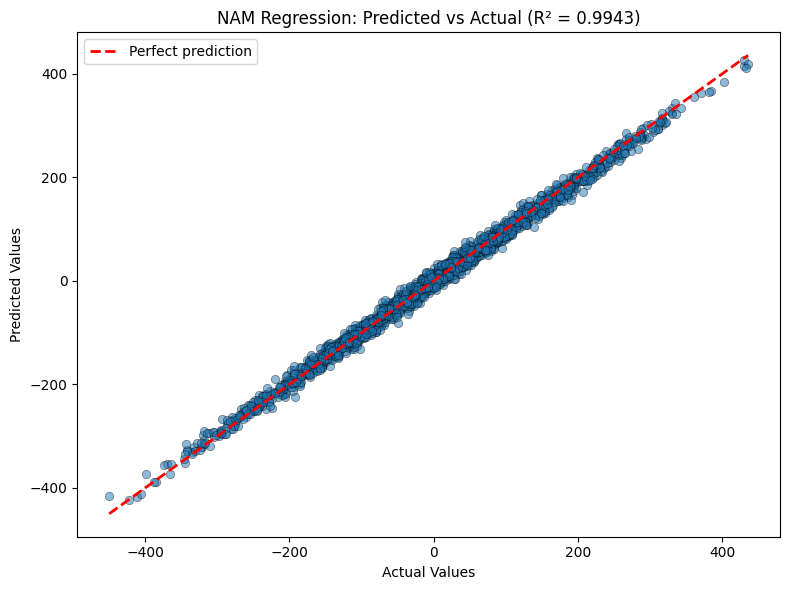

In [60]:
# Visualize predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'NAM Regression: Predicted vs Actual (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Visualizing Shape Functions

One of the key advantages of NAMs is interpretability. We can visualize how each feature contributes to the prediction through shape functions.

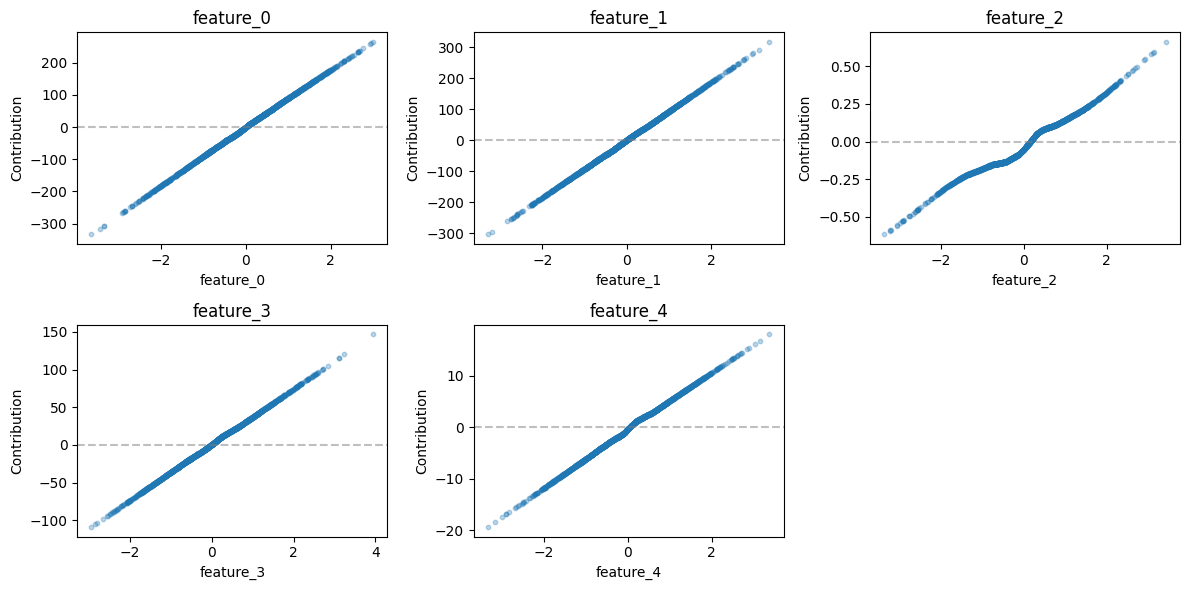

(<Figure size 1200x600 with 6 Axes>,
 array([<Axes: title={'center': 'feature_0'}, xlabel='feature_0', ylabel='Contribution'>,
        <Axes: title={'center': 'feature_1'}, xlabel='feature_1', ylabel='Contribution'>,
        <Axes: title={'center': 'feature_2'}, xlabel='feature_2', ylabel='Contribution'>,
        <Axes: title={'center': 'feature_3'}, xlabel='feature_3', ylabel='Contribution'>,
        <Axes: title={'center': 'feature_4'}, xlabel='feature_4', ylabel='Contribution'>,
        <Axes: >], dtype=object))

In [61]:
# Plot shape functions for each feature
plot_shape_functions(model, X_test, max_cols=3)


## 4. Real-World Dataset: California Housing

Let's apply NAMpy to a real-world dataset - the California Housing dataset.

In [62]:
# Load California Housing dataset
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

print(f"Dataset shape: {X_housing.shape}")
print(f"\nFeature names: {housing.feature_names}")
print(f"\nTarget: Median house value (in $100,000s)")
X_housing.describe()


Dataset shape: (20640, 8)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: Median house value (in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [63]:
# Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_h)}")
print(f"Test samples: {len(X_test_h)}")

Training samples: 16512
Test samples: 4128


In [64]:
# Train NAM on California Housing
model_housing = NAMRegressor(
    numerical_preprocessing="ple",  # Piecewise Linear Encoding
    n_bins=50,
    dropout=0.2,
    layer_sizes=[128, 64, 32],
)

model_housing.fit(
    X_train_h, 
    y_train_h, 
    max_epochs=100,
    lr=1e-3,
    patience=10,
    batch_size=256
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ad32/projects/test/NAMpy/docs/notebooks/model_checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fct │ MSELoss │      0 │ train │     0 │
│ 1 │ model    │ NAM     │  135 K │ train │     0 │
└───┴──────────┴─────────┴────────┴───────┴───────┘

Trainable params: 135 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 135 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 69                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

Output()

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.p
y:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.p
y:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/home/ad32/miniconda3/envs/nampy/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 1 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

,dropout,0.2
,layer_sizes,"[128, 64, ...]"
,preprocessor__n_bins,50
,preprocessor__numerical_preprocessing,'ple'
,preprocessor__categorical_preprocessing,'int'
,preprocessor__use_decision_tree_bins,False
,preprocessor__binning_strategy,'uniform'
,preprocessor__task,'regression'
,preprocessor__cat_cutoff,0.03
,preprocessor__treat_all_integers_as_numerical,False
,preprocessor__degree,3


In [65]:
# Evaluate on test set
y_pred_h = model_housing.predict(X_test_h)

mse_h = mean_squared_error(y_test_h, y_pred_h)
rmse_h = np.sqrt(mse_h)
mae_h = mean_absolute_error(y_test_h, y_pred_h)
r2_h = r2_score(y_test_h, y_pred_h)

print("California Housing - NAM Performance:")
print(f"  MSE:  {mse_h:.4f}")
print(f"  RMSE: {rmse_h:.4f}")
print(f"  MAE:  {mae_h:.4f}")
print(f"  R²:   {r2_h:.4f}")

California Housing - NAM Performance:
  MSE:  0.3368
  RMSE: 0.5804
  MAE:  0.4107
  R²:   0.7430


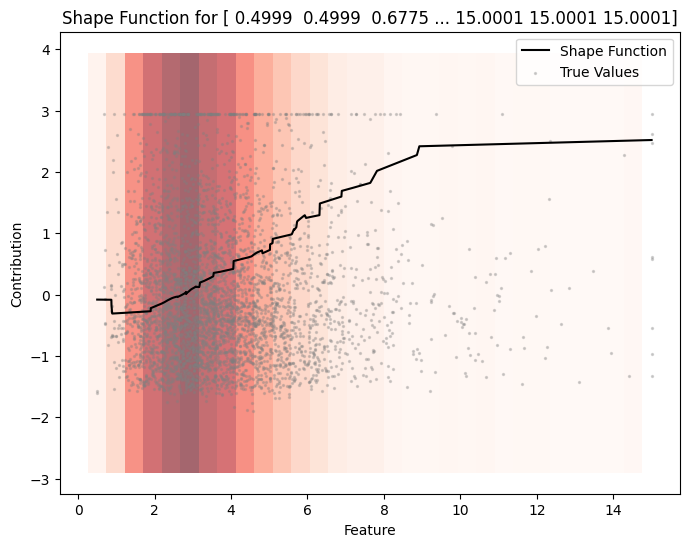

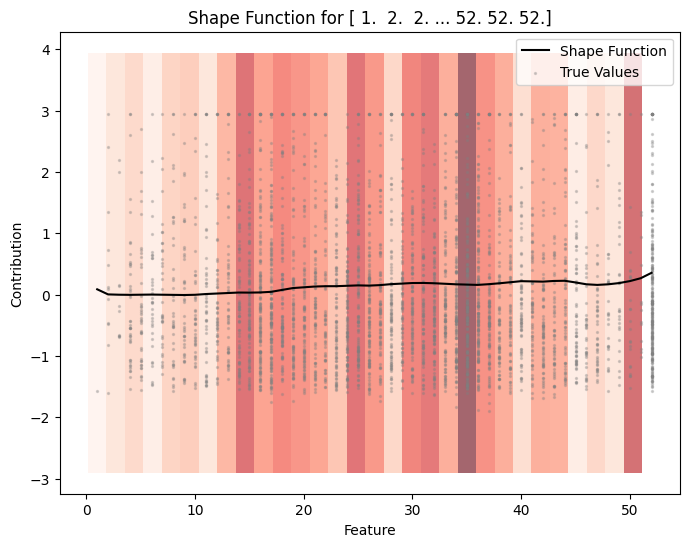

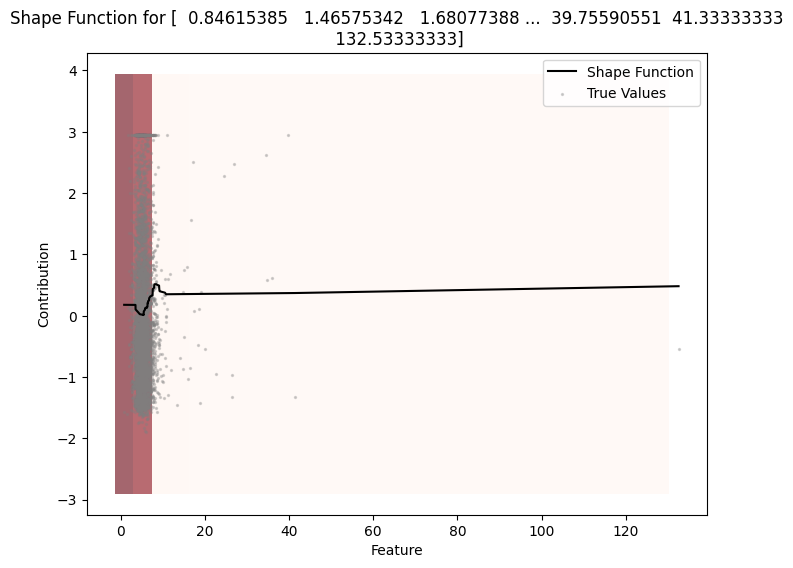

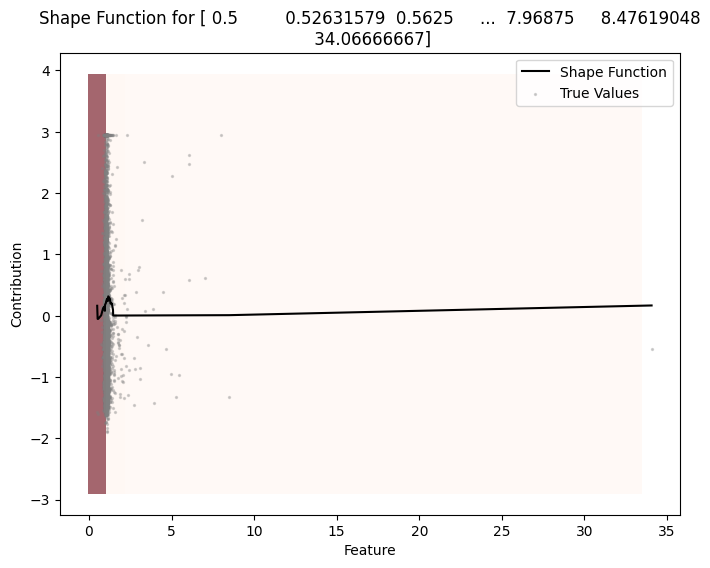

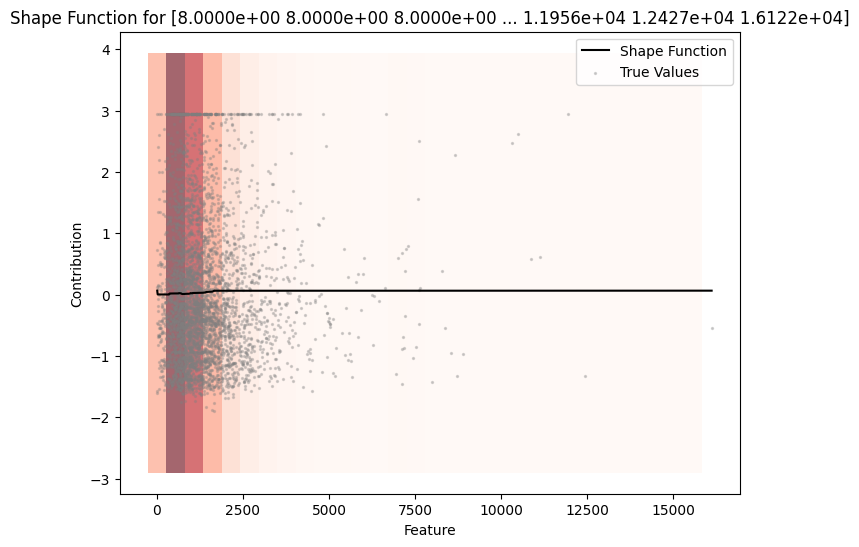

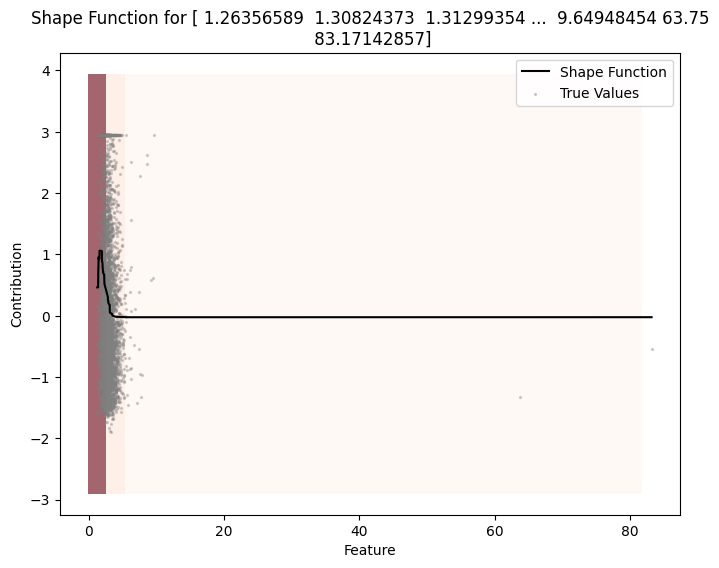

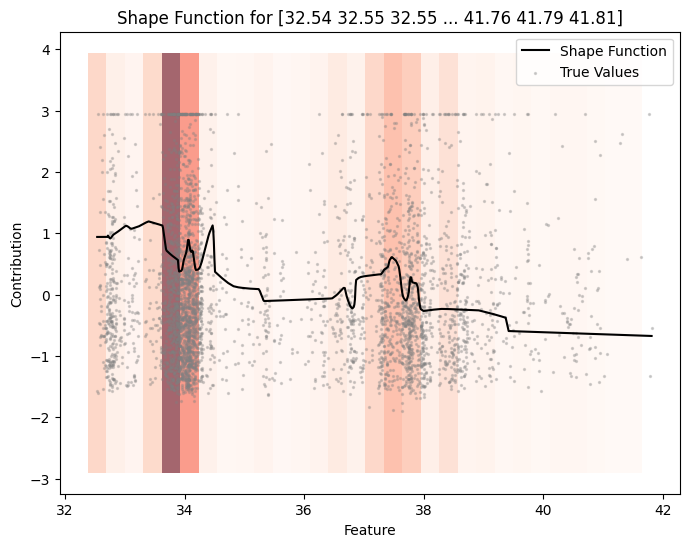

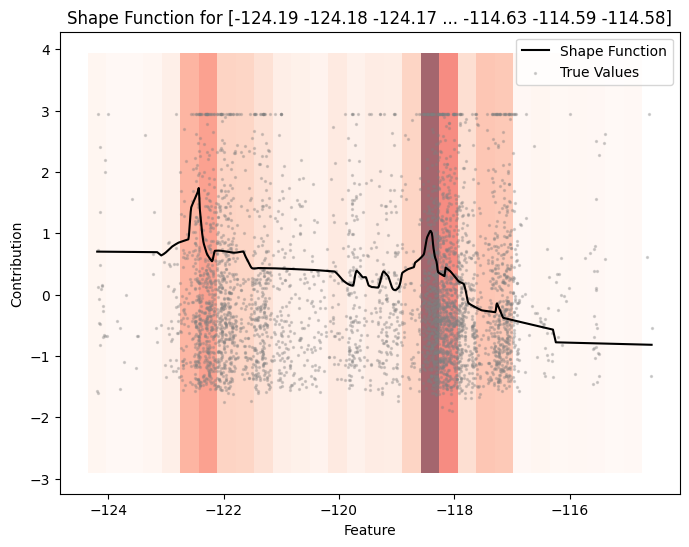

In [66]:
model_housing.plot(X_test_h, y_test_h)

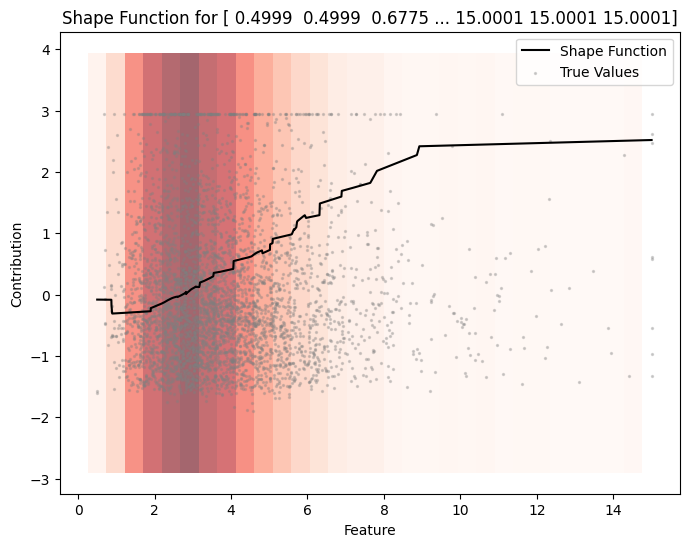

In [67]:
# To use _plot_single_feature_effects directly, we need to:
# 1. Generate predictions (which returns a dictionary with feature names as keys)
# 2. Select a specific feature
# 3. Extract that feature's values and predictions

import pandas as pd
import numpy as np

# Generate predictions for all features
X_test_df = pd.DataFrame(X_test_h)
predictions = model_housing._predict(X_test_df)

# Get the first numerical feature name
feature_name = None
for col in X_test_df.columns:
    if pd.api.types.is_numeric_dtype(X_test_df[col]) and col in predictions:
        feature_name = col
        break

if feature_name:
    # Sort the feature values for plotting
    X_sorted = X_test_df[feature_name].sort_values().values
    
    # Get predictions for this feature (need to re-predict with sorted values)
    X_simulated = X_test_df.copy()
    X_simulated[feature_name] = X_sorted
    predictions_sorted = model_housing._predict(X_simulated)
    
    # Plot the single feature effect
    model_housing._plot_single_feature_effects(
        X_sorted, 
        predictions_sorted[feature_name], 
        y_test_h
    )
else:
    print("No numerical features found in predictions")